<a href="https://colab.research.google.com/github/eliecer17882021/TalentoTech/blob/main/Calsificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset
df = pd.read_csv('/content/smartprix_smartphones_april_2026.csv')

# Eliminar las columnas especificadas
columns_to_drop = ['spec_score', 'vfm_score', 'num_core', 'processor_speed', 'charging_ratio']
df = df.drop(columns=columns_to_drop, errors='ignore')

print("Primeras 5 filas del dataset:")
display(df.head())

Primeras 5 filas del dataset:


,brand_name,model,price_category,price,vfm_label,has_5G,has_NFC,has_IR,processor_brand,processor_name,...,memory,battery_capacity(mAh),fast_charging(W),charging_speed_type,screen_size,refresh_rate,rear_camera,front_camera,rear_camera_count,os
0,oneplus,OnePlus Nord 6,Premium,38999,Average Value,True,True,True,qualcomm,Snapdragon 8s Gen4,...,256.0,9000.0,80.0,Standard,6.78,165.0,50.0,32.0,2,Android v16
1,samsung,Samsung Galaxy S25 Ultra,Flagship,110000,Average Value,True,True,False,qualcomm,Snapdragon 8 Elite for Galaxy,...,256.0,5000.0,45.0,Standard,6.90,120.0,200.0,12.0,4,Android v15
2,vivo,Vivo T5 Pro,Mid-Range,29999,Value King,True,False,True,qualcomm,Snapdragon 7s Gen4,...,128.0,9020.0,90.0,Standard,6.80,120.0,50.0,50.0,3,Android v16
3,samsung,Samsung Galaxy S25 FE,Premium,50743,Average Value,True,True,False,samsung,Exynos 2400,...,128.0,4900.0,45.0,Standard,6.70,120.0,50.0,12.0,3,Android v16
4,vivo,Vivo T5x 5G,Mid-Range,18999,Average Value,True,False,True,mediatek,Dimensity 7400 Turbo,...,128.0,7200.0,44.0,Standard,6.76,120.0,50.0,32.0,2,Android v16


In [2]:
print("Información general del dataset:")
df.info()

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 997 entries, 0 to 996
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand_name             997 non-null    object 
 1   model                  997 non-null    object 
 2   price_category         997 non-null    object 
 3   price                  997 non-null    int64  
 4   spec_score             997 non-null    int64  
 5   vfm_score              997 non-null    float64
 6   vfm_label              997 non-null    object 
 7   has_5G                 997 non-null    bool   
 8   has_NFC                997 non-null    bool   
 9   has_IR                 997 non-null    bool   
 10  processor_brand        996 non-null    object 
 11  processor_name         997 non-null    object 
 12  num_core               980 non-null    float64
 13  processor_speed        862 non-null    float64
 14  ram                    99

In [3]:
print("Estadísticas descriptivas del dataset:")
display(df.describe())

Estadísticas descriptivas del dataset:


,price,spec_score,vfm_score,num_core,processor_speed,ram,memory,battery_capacity(mAh),fast_charging(W),charging_ratio,screen_size,refresh_rate,rear_camera,front_camera,rear_camera_count
count,997.000000,997.000000,9.970000e+02,980.000000,862.000000,997.000000,997.000000,997.000000,941.000000,941.000000,997.000000,948.000000,981.000000,979.000000,997.000000
mean,38153.403210,66.827482,3.420868e-16,7.964286,2.803109,8.600802,209.853561,5910.256770,71.273114,143.846701,6.799198,123.291139,61.993068,22.706946,2.345035
std,41182.544768,12.380527,9.984928e-01,0.482323,0.666099,3.146541,114.782038,1206.023264,365.592799,98.418805,1.875693,16.420801,43.120843,15.485954,0.654999
min,4999.000000,23.000000,-4.914255e+00,1.000000,1.300000,2.000000,1.000000,6.200000,10.000000,0.625000,4.000000,90.000000,8.000000,5.000000,1.000000
25%,16799.000000,58.000000,-6.549316e-01,8.000000,2.400000,6.000000,128.000000,5000.000000,33.000000,75.000000,6.670000,120.000000,50.000000,10.000000,2.000000
50%,25999.000000,66.000000,1.176810e-01,8.000000,2.500000,8.000000,256.000000,5800.000000,45.000000,112.500000,6.740000,120.000000,50.000000,16.000000,2.000000
75%,42990.000000,76.000000,6.525773e-01,8.000000,3.200000,12.000000,256.000000,6580.000000,80.000000,170.000000,6.780000,120.000000,50.000000,32.000000,3.000000
max,489990.000000,98.000000,2.392201e+00,10.000000,4.740000,24.000000,512.000000,13080.000000,11200.000000,600.000000,48.000000,240.000000,200.000000,60.000000,4.000000


In [4]:
print("Valores nulos por columna:")
display(df.isnull().sum()[df.isnull().sum() > 0])

Valores nulos por columna:


,0
processor_brand,1
num_core,17
processor_speed,135
fast_charging(W),56
charging_ratio,56
refresh_rate,49
rear_camera,16
front_camera,18
os,11


### Análisis de variables numéricas y categóricas

Vamos a identificar los tipos de datos y las columnas con muchos valores únicos, lo que nos ayudará a entender mejor las características de cada variable.

In [5]:
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("Columnas Numéricas:", numerical_cols.tolist())
print("Columnas Categóricas:", categorical_cols.tolist())

print("\nValores únicos para algunas columnas categóricas (primeras 10):")
for col in categorical_cols:
    if df[col].nunique() < 20:
        print(f"- {col}: {df[col].unique()}")
    else:
        print(f"- {col}: {df[col].nunique()} valores únicos (mostrando los 10 primeros: {df[col].unique()[:10]})")

Columnas Numéricas: ['price', 'spec_score', 'vfm_score', 'num_core', 'processor_speed', 'ram', 'memory', 'battery_capacity(mAh)', 'fast_charging(W)', 'charging_ratio', 'screen_size', 'refresh_rate', 'rear_camera', 'front_camera', 'rear_camera_count']
Columnas Categóricas: ['brand_name', 'model', 'price_category', 'vfm_label', 'processor_brand', 'processor_name', 'charging_speed_type', 'os']

Valores únicos para algunas columnas categóricas (primeras 10):
- brand_name: 36 valores únicos (mostrando los 10 primeros: ['oneplus' 'samsung' 'vivo' 'motorola' 'xiaomi' 'realme' 'infinix' 'iqoo'
 'apple' 'oppo'])
- model: 997 valores únicos (mostrando los 10 primeros: ['OnePlus Nord 6' 'Samsung Galaxy S25 Ultra' 'Vivo T5 Pro'
 'Samsung Galaxy S25 FE' 'Vivo T5x 5G' 'Vivo T5 5G'
 'Motorola Edge 70 Fusion' 'Xiaomi Redmi Note 15 5G Special Edition'
 'Realme 16 5G' 'Vivo V70 FE'])
- price_category: ['Premium' 'Flagship' 'Mid-Range' 'Budget']
- vfm_label: ['Average Value' 'Value King' 'Overpriced' 'Pe

### Visualización de distribuciones

Ahora, visualicemos las distribuciones de algunas de las variables clave para entender su comportamiento.

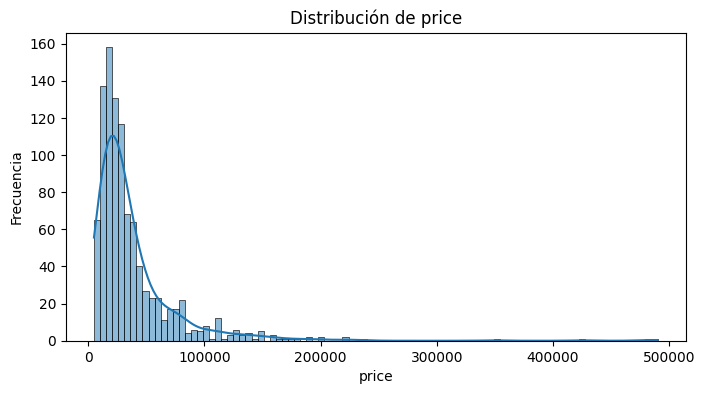

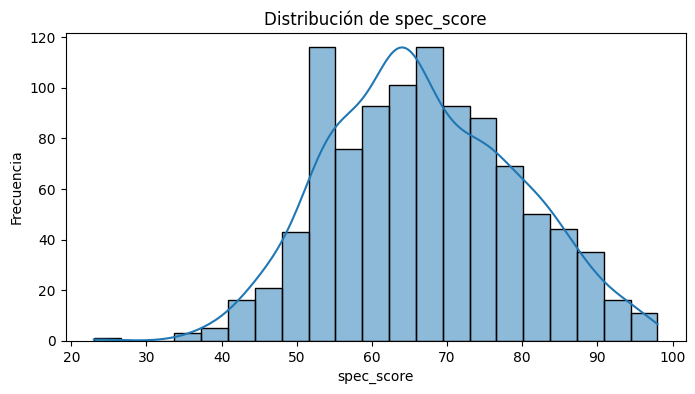

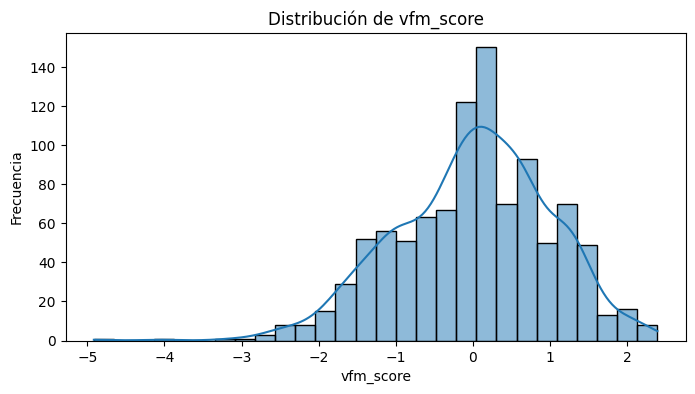

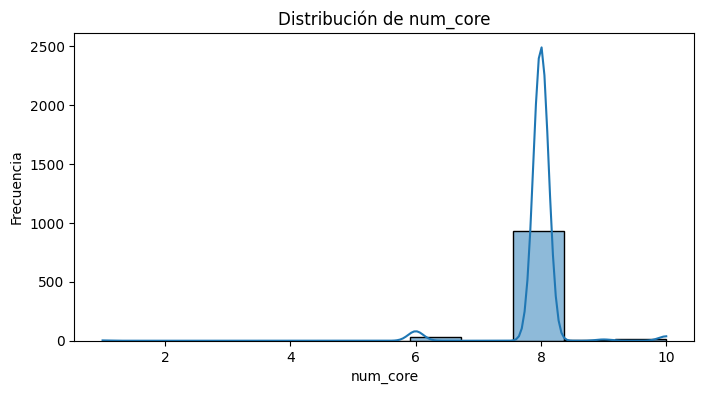

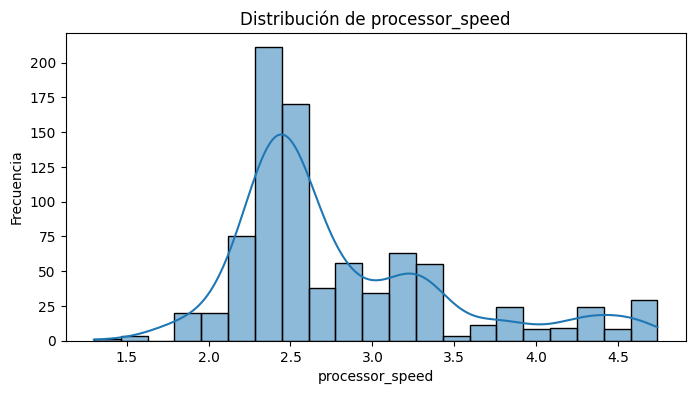

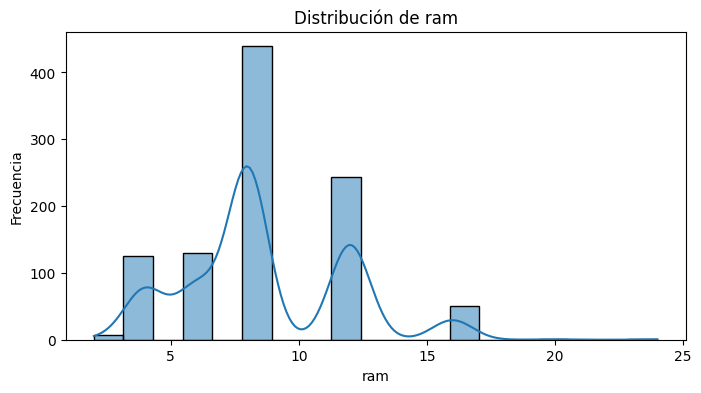

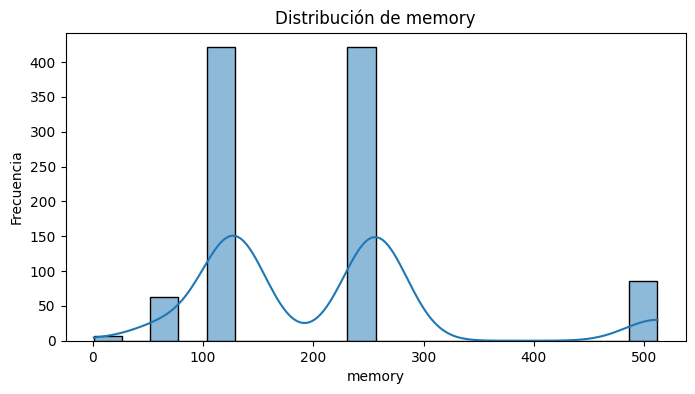

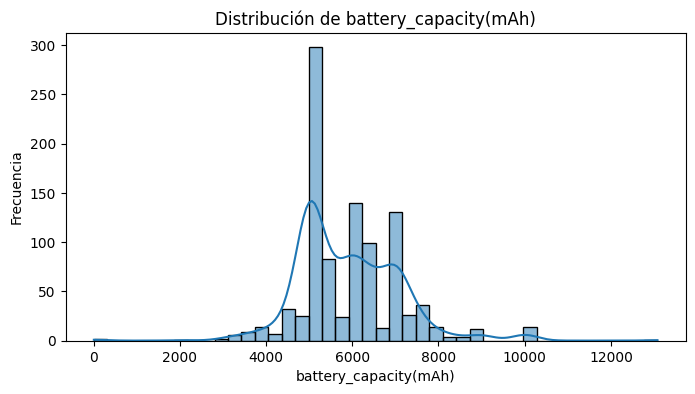

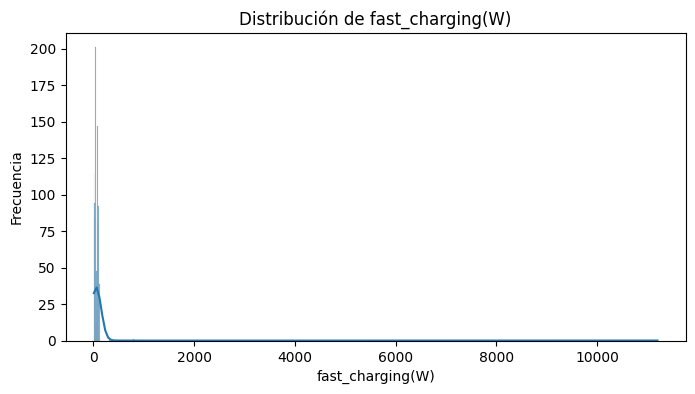

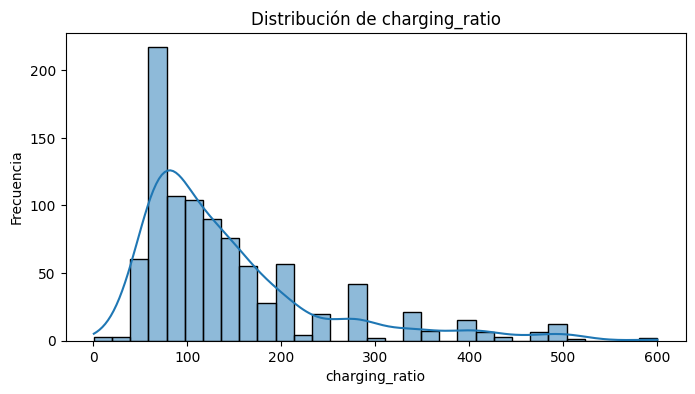

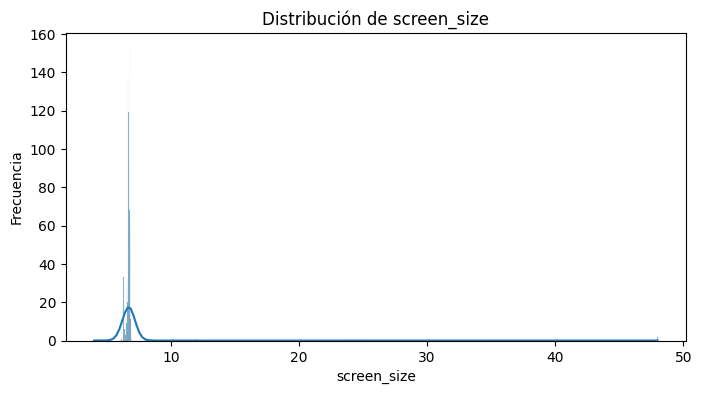

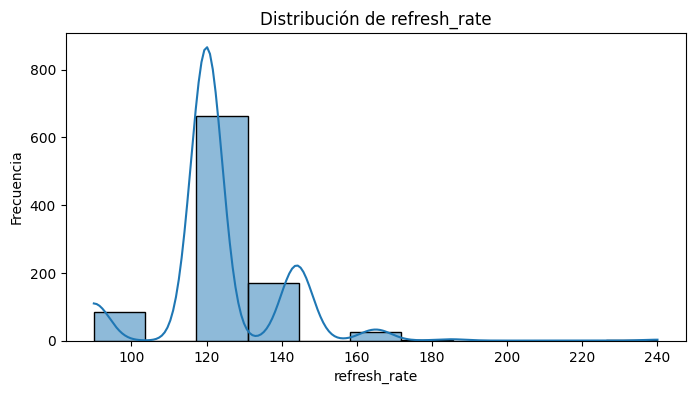

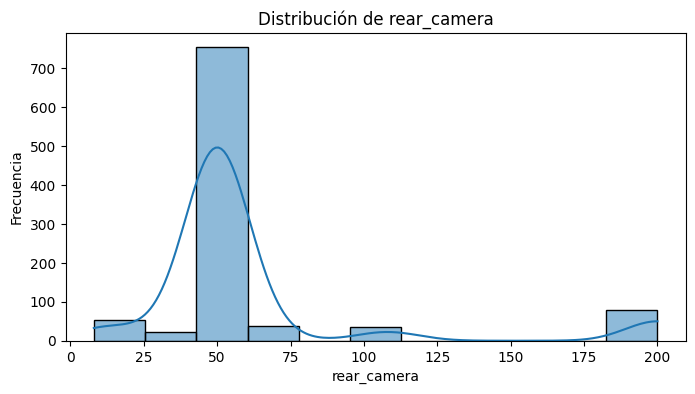

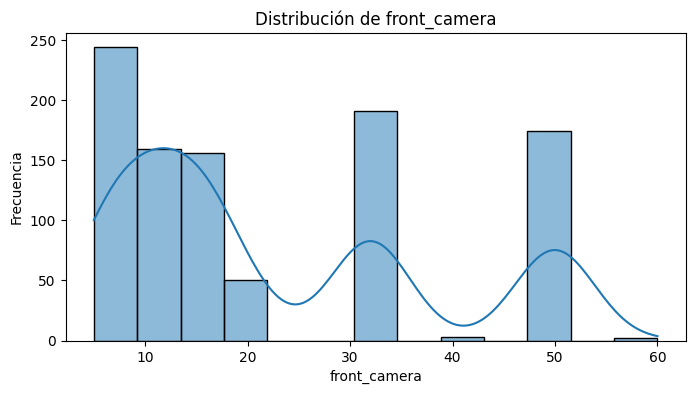

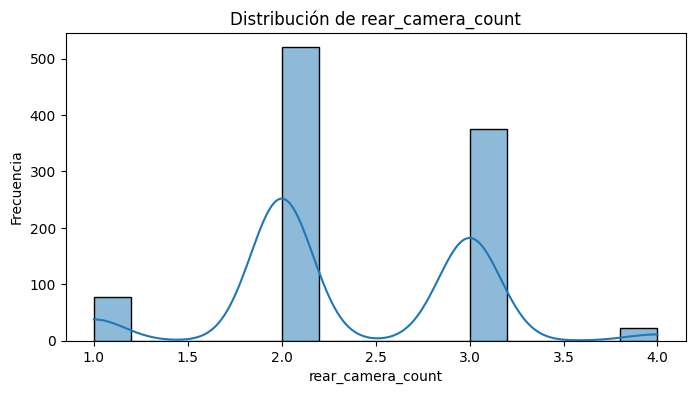

In [6]:
# Histograma para variables numéricas
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

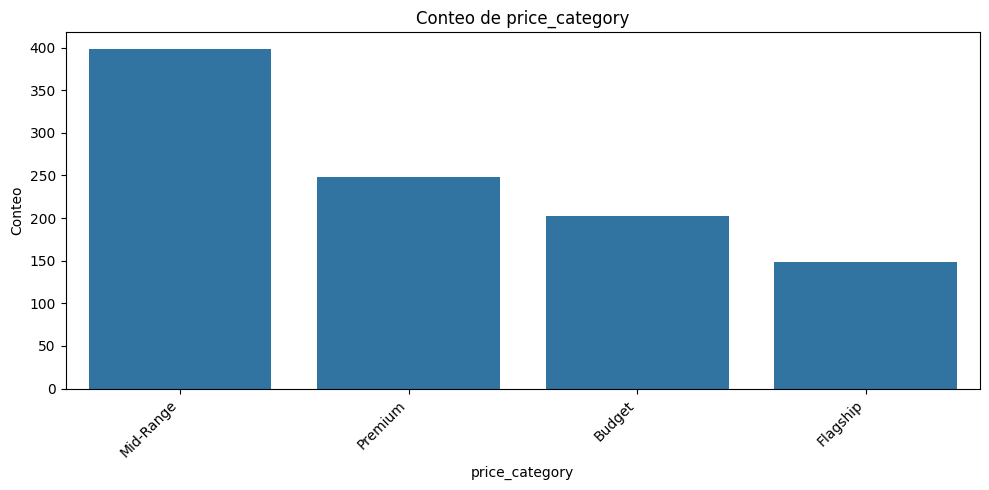

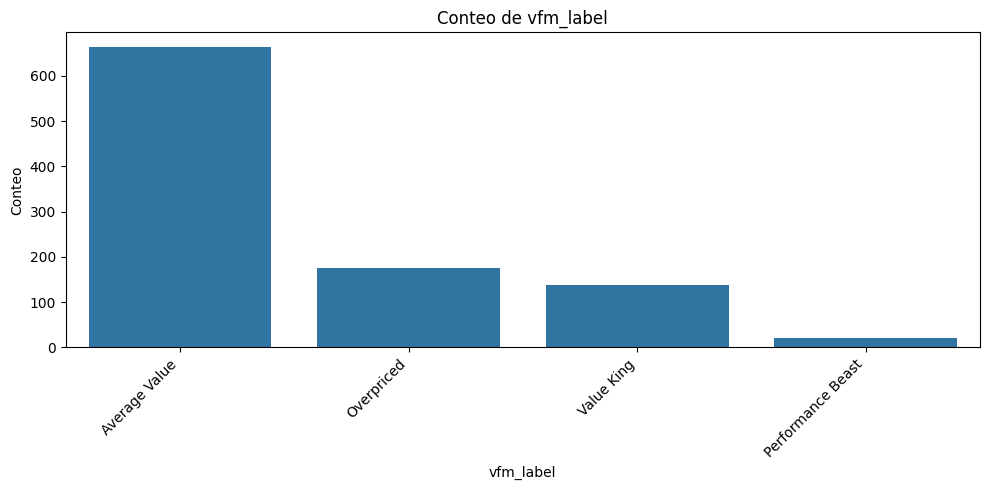

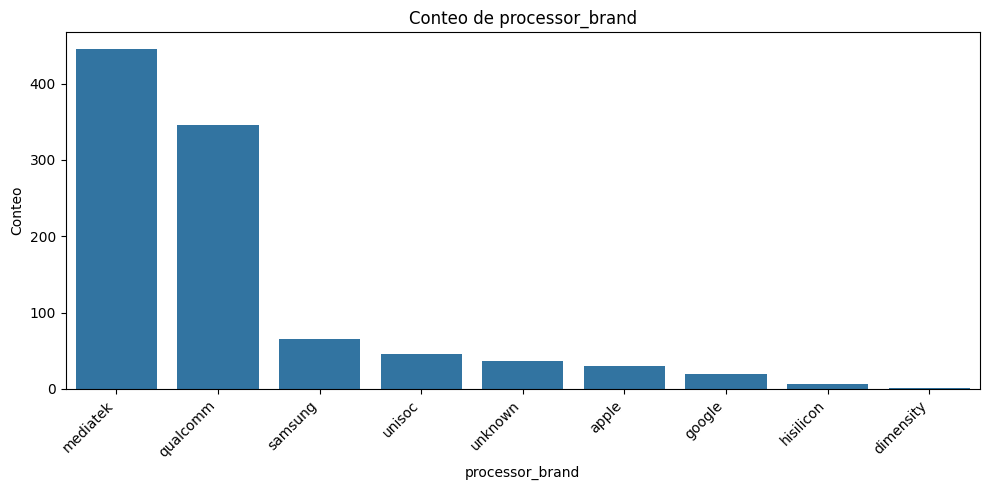

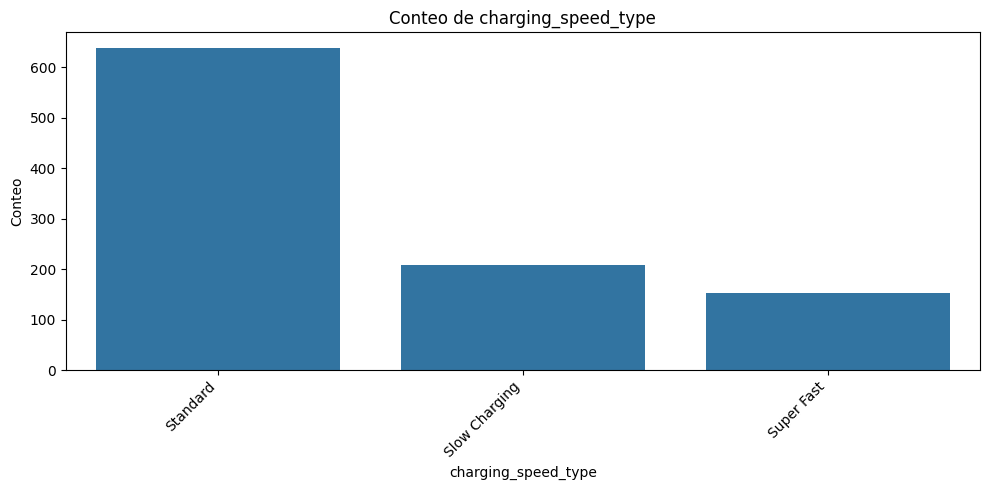

In [7]:
# Gráfico de barras para variables categóricas con pocos valores únicos
for col in categorical_cols:
    if df[col].nunique() < 20 and df[col].nunique() > 1:
        plt.figure(figsize=(10, 5))
        sns.countplot(data=df, x=col, order=df[col].value_counts().index)
        plt.title(f'Conteo de {col}')
        plt.xlabel(col)
        plt.ylabel('Conteo')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

## Preparación de Datos para el Modelo de Regresión Logística

Primero, definiremos la variable objetivo (`price_category`) y las características (el resto de las columnas). Luego, abordaremos los valores nulos, codificaremos las variables categóricas y escalaremos las características numéricas.

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Definir la variable objetivo
y = df['price_category']

# Columnas adicionales a eliminar, según la solicitud del usuario
columns_to_remove_from_X = ['spec_score', 'vfm_score', 'num_core', 'processor_speed', 'charging_ratio']

X = df.drop(['price_category', 'model'] + columns_to_remove_from_X, axis=1, errors='ignore') # 'model' se elimina por su alta cardinalidad

# Codificar la variable objetivo 'price_category'
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Clases de price_category codificadas: {label_encoder.classes_}")
print(f"Primeros 5 valores de la variable objetivo codificada: {y_encoded[:5]}")

Clases de price_category codificadas: ['Budget' 'Flagship' 'Mid-Range' 'Premium']
Primeros 5 valores de la variable objetivo codificada: [3 1 2 3 2]


In [49]:
# Identificar columnas numéricas y categóricas después de eliminar 'price_category' y 'model'
numerical_features = X.select_dtypes(include=['number', 'bool']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Crear pipelines de preprocesamiento
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combinar los transformadores con ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Aplicar el preprocesamiento a X
X_preprocessed = preprocessor.fit_transform(X)

print("Dimensiones de las características preprocesadas:", X_preprocessed.shape)

Dimensiones de las características preprocesadas: (997, 287)


In [50]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y_encoded, test_size=0.2, random_state=42)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

Dimensiones de X_train: (797, 287)
Dimensiones de X_test: (200, 287)
Dimensiones de y_train: (797,)
Dimensiones de y_test: (200,)


In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize
import numpy as np

# Inicializar y entrenar el modelo de Regresión Logística (Multi-clase)
# Se utiliza solver='liblinear' para manejar problemas multi-clase con OneVsRestClassifier
# Se ajusta max_iter para asegurar la convergencia
log_reg_model = LogisticRegression(solver='lbfgs', multi_class='multinomial', max_iter=1000, random_state=42)
log_reg_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = log_reg_model.predict(X_test)
y_pred_proba = log_reg_model.predict_proba(X_test)

print("Modelo de Regresión Logística entrenado y predicciones realizadas.")

Modelo de Regresión Logística entrenado y predicciones realizadas.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [52]:
# Aplicar el preprocesador (ya ajustado en X_train) a los nuevos datos
new_X_preprocessed = preprocessor.transform(new_df)

print("Dimensiones de los nuevos datos preprocesados:", new_X_preprocessed.shape)

Dimensiones de los nuevos datos preprocesados: (1, 287)


In [53]:
# Realizar la predicción
prediction_encoded = log_reg_model.predict(new_X_preprocessed)
prediction_proba = log_reg_model.predict_proba(new_X_preprocessed)

# Decodificar la predicción
predicted_category = label_encoder.inverse_transform(prediction_encoded)

print(f"La categoría de precio predicha para el nuevo smartphone es: {predicted_category[0]}")

# Mostrar las probabilidades para cada clase
print("Probabilidades de predicción por clase:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"- {class_name}: {prediction_proba[0, i]:.4f}")

La categoría de precio predicha para el nuevo smartphone es: Flagship
Probabilidades de predicción por clase:
- Budget: 0.0000
- Flagship: 1.0000
- Mid-Range: 0.0000
- Premium: 0.0000


### Manejo de Valores Nulos y Codificación de Variables

Crearemos pipelines para preprocesar las columnas numéricas y categóricas por separado.

In [9]:
# Identificar columnas numéricas y categóricas después de eliminar 'price_category' y 'model'
numerical_features = X.select_dtypes(include=['number', 'bool']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Crear pipelines de preprocesamiento
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combinar los transformadores con ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Aplicar el preprocesamiento a X
X_preprocessed = preprocessor.fit_transform(X)

print("Dimensiones de las características preprocesadas:", X_preprocessed.shape)

Dimensiones de las características preprocesadas: (997, 292)


### División de Datos en Conjuntos de Entrenamiento y Prueba

Dividiremos el dataset para evaluar el rendimiento del modelo en datos no vistos.

In [10]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y_encoded, test_size=0.2, random_state=42)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

Dimensiones de X_train: (797, 292)
Dimensiones de X_test: (200, 292)
Dimensiones de y_train: (797,)
Dimensiones de y_test: (200,)


## Modelo de Regresión Logística y Evaluación

Ahora construiremos y entrenaremos el modelo de Regresión Logística, y luego realizaremos las evaluaciones solicitadas: Matriz de Confusión, Reporte de Clasificación, Curva ROC, AUC e Histograma de Errores.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize
import numpy as np

# Inicializar y entrenar el modelo de Regresión Logística (Multi-clase)
# Se utiliza solver='liblinear' para manejar problemas multi-clase con OneVsRestClassifier
# Se ajusta max_iter para asegurar la convergencia
log_reg_model = LogisticRegression(solver='lbfgs', multi_class='multinomial', max_iter=1000, random_state=42)
log_reg_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = log_reg_model.predict(X_test)
y_pred_proba = log_reg_model.predict_proba(X_test)

print("Modelo de Regresión Logística entrenado y predicciones realizadas.")

Modelo de Regresión Logística entrenado y predicciones realizadas.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### Matriz de Confusión

La matriz de confusión nos muestra el rendimiento del modelo en términos de verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos para cada clase.

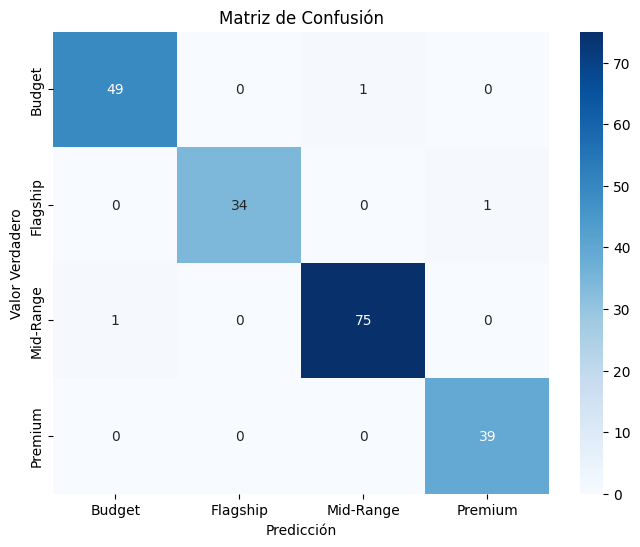

In [12]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Verdadero')
plt.show()

### Reporte de Clasificación

El reporte de clasificación proporciona métricas clave como precisión, recall, f1-score y soporte para cada clase, así como promedios.

In [13]:
class_report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
print("Reporte de Clasificación:\n", class_report)

Reporte de Clasificación:
               precision    recall  f1-score   support

      Budget       0.98      0.98      0.98        50
    Flagship       1.00      0.97      0.99        35
   Mid-Range       0.99      0.99      0.99        76
     Premium       0.97      1.00      0.99        39

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



### Curva ROC y AUC (Para Multi-clase)

Para modelos multi-clase, podemos calcular la Curva ROC y el AUC para cada clase utilizando una estrategia "uno contra el resto" (OvR).

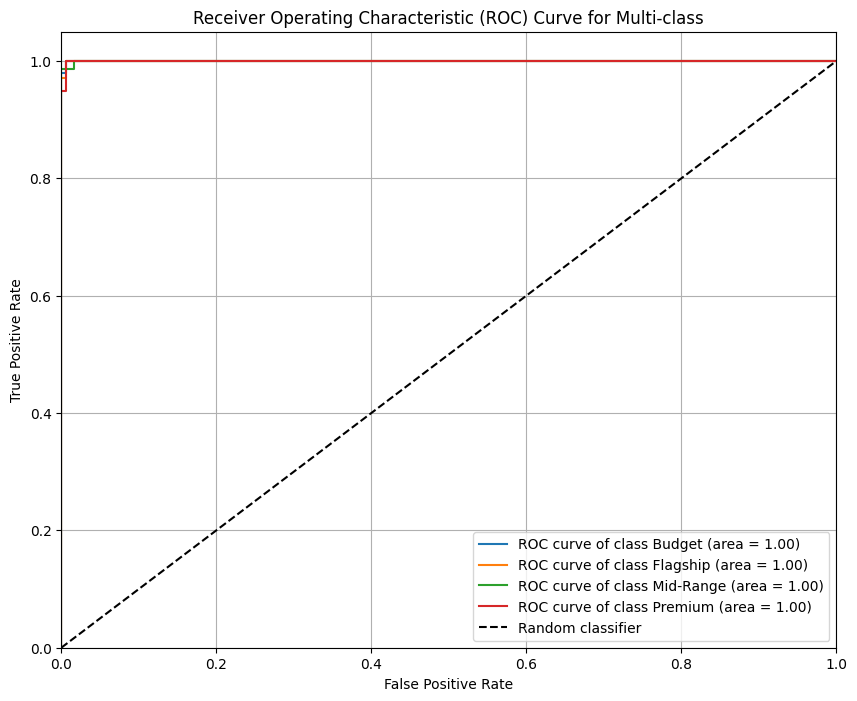

In [14]:
# Binarizar la salida para el cálculo de ROC y AUC para multi-clase (One-vs-Rest)
y_test_binarized = label_binarize(y_test, classes=np.arange(len(label_encoder.classes_)))
n_classes = y_test_binarized.shape[1]

# Calcular la curva ROC y el área AUC para cada clase
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Dibujar las curvas ROC
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {label_encoder.classes_[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Multi-class')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Histograma de Errores (Residuos)

Para clasificación, un "histograma de errores" puede interpretarse como la distribución de las probabilidades predichas para las clases correctas vs. incorrectas, o más comúnmente, la distribución de la diferencia entre la probabilidad predicha y el valor real (aunque no es tan directo como en regresión). Aquí, podemos visualizar la distribución de las probabilidades de las predicciones correctas e incorrectas.

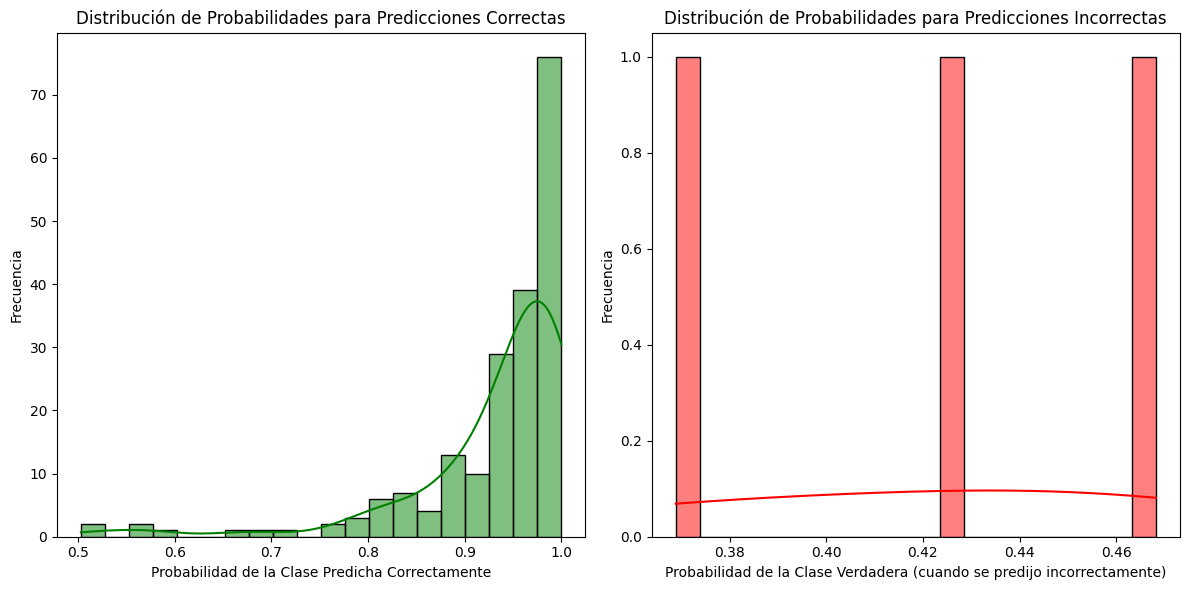

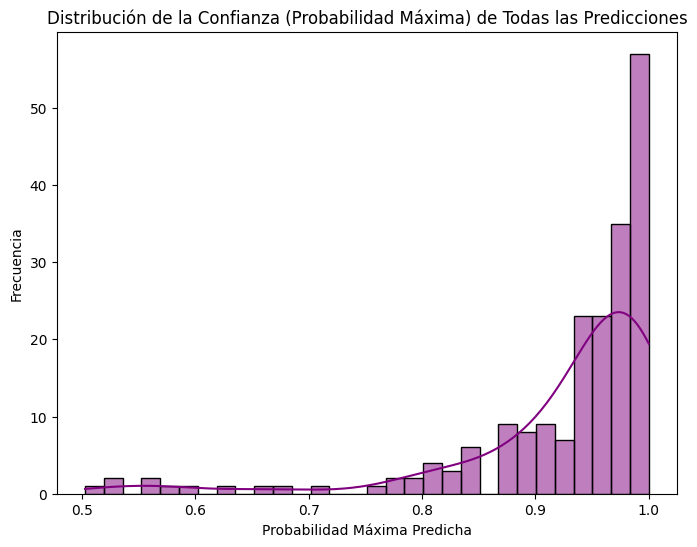

In [15]:
# Calcular las probabilidades de la clase predicha
# Obtener las probabilidades de la clase a la que se predijo que pertenece cada instancia
predicted_class_probabilities = np.array([y_pred_proba[i, pred_class] for i, pred_class in enumerate(y_pred)])

# Calcular las probabilidades de la clase verdadera
# Esto requiere saber el índice de la clase verdadera para cada instancia
true_class_probabilities = np.array([y_pred_proba[i, true_class] for i, true_class in enumerate(y_test)])

# Visualizar la distribución de las probabilidades de las predicciones correctas e incorrectas
plt.figure(figsize=(12, 6))

# Histograma para predicciones correctas (donde y_test == y_pred)
plt.subplot(1, 2, 1)
correct_predictions_proba = true_class_probabilities[y_test == y_pred]
sns.histplot(correct_predictions_proba, bins=20, kde=True, color='green')
plt.title('Distribución de Probabilidades para Predicciones Correctas')
plt.xlabel('Probabilidad de la Clase Predicha Correctamente')
plt.ylabel('Frecuencia')

# Histograma para predicciones incorrectas (donde y_test != y_pred)
plt.subplot(1, 2, 2)
incorrect_predictions_proba = true_class_probabilities[y_test != y_pred]
sns.histplot(incorrect_predictions_proba, bins=20, kde=True, color='red')
plt.title('Distribución de Probabilidades para Predicciones Incorrectas')
plt.xlabel('Probabilidad de la Clase Verdadera (cuando se predijo incorrectamente)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# También podemos ver la distribución de la confianza (probabilidad más alta) de todas las predicciones
plt.figure(figsize=(8, 6))
sns.histplot(np.max(y_pred_proba, axis=1), bins=30, kde=True, color='purple')
plt.title('Distribución de la Confianza (Probabilidad Máxima) de Todas las Predicciones')
plt.xlabel('Probabilidad Máxima Predicha')
plt.ylabel('Frecuencia')
plt.show()

## Prueba del Modelo con Datos Manuales

A continuación, ingresaremos los datos para un nuevo smartphone y veremos cómo nuestro modelo predice su `price_category`.

In [57]:
import pandas as pd

# Crear un DataFrame con los datos de un nuevo smartphone
# Asegúrate de que las columnas coincidan con las características usadas para entrenar (excepto 'price_category' y 'model')
new_smartphone_data = {
    'brand_name': ['Xiaomi'],
    'price': [25000],
    'has_5G': [True],
    'has_NFC': [False],
    'has_IR': [True],
    'processor_brand': ['mediatek'],
    'processor_name': ['Dimensity 810'],
    'ram': [6.0],
    'memory': [128.0],
    'battery_capacity(mAh)': [4500.0],
    'fast_charging(W)': [18.0],
    'charging_speed_type': ['Standard'],
    'screen_size': [6.6],
    'refresh_rate': [90.0],
    'rear_camera': [50.0],
    'front_camera': [16.0],
    'rear_camera_count': [2],
    'os': ['Android v13'],
    'vfm_label': ['Value King']
}

new_df = pd.DataFrame(new_smartphone_data)
display(new_df)

,brand_name,price,has_5G,has_NFC,has_IR,processor_brand,processor_name,ram,memory,battery_capacity(mAh),fast_charging(W),charging_speed_type,screen_size,refresh_rate,rear_camera,front_camera,rear_camera_count,os,vfm_label
0,Xiaomi,25000,True,False,True,mediatek,Dimensity 810,6.0,128.0,4500.0,18.0,Standard,6.6,90.0,50.0,16.0,2,Android v13,Value King


In [58]:
# Aplicar el preprocesador (ya ajustado en X_train) a los nuevos datos
new_X_preprocessed = preprocessor.transform(new_df)

print("Dimensiones de los nuevos datos preprocesados:", new_X_preprocessed.shape)

Dimensiones de los nuevos datos preprocesados: (1, 287)


In [59]:
# Realizar la predicción
prediction_encoded = log_reg_model.predict(new_X_preprocessed)
prediction_proba = log_reg_model.predict_proba(new_X_preprocessed)

# Decodificar la predicción
predicted_category = label_encoder.inverse_transform(prediction_encoded)

print(f"La categoría de precio predicha para el nuevo smartphone es: {predicted_category[0]}")

# Mostrar las probabilidades para cada clase
print("Probabilidades de predicción por clase:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"- {class_name}: {prediction_proba[0, i]:.4f}")

La categoría de precio predicha para el nuevo smartphone es: Budget
Probabilidades de predicción por clase:
- Budget: 0.9440
- Flagship: 0.0000
- Mid-Range: 0.0559
- Premium: 0.0001


### Preprocesamiento de los Nuevos Datos

Es crucial aplicar el mismo preprocesamiento que usamos en los datos de entrenamiento para asegurar que el modelo reciba las características en el formato esperado.

### Predicción de la Categoría de Precio

Ahora usaremos nuestro modelo de Regresión Logística para predecir la `price_category` del nuevo smartphone.

In [37]:
# Realizar la predicción
prediction_encoded = log_reg_model.predict(new_X_preprocessed)
prediction_proba = log_reg_model.predict_proba(new_X_preprocessed)

# Decodificar la predicción
predicted_category = label_encoder.inverse_transform(prediction_encoded)

print(f"La categoría de precio predicha para el nuevo smartphone es: {predicted_category[0]}")

# Mostrar las probabilidades para cada clase
print("Probabilidades de predicción por clase:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"- {class_name}: {prediction_proba[0, i]:.4f}")

La categoría de precio predicha para el nuevo smartphone es: Flagship
Probabilidades de predicción por clase:
- Budget: 0.0000
- Flagship: 1.0000
- Mid-Range: 0.0000
- Premium: 0.0000


In [40]:
print(label_encoder.classes_)

['Budget' 'Flagship' 'Mid-Range' 'Premium']
